### Fine-tuning geneformer for cell type classification 

This tutorial covers end-to-end fine-tuning of a single-cell foundation model in DECONVersation using Geneformer. It walks through preparing an annotated single-cell reference, tokenizing it for the model, building class-balanced train, evaluation, and held-out test splits, and fine-tuning a pretrained Geneformer model for cell type classification. Performance is assessed on the held-out test set using accuracy and macro F1. While this tutorial uses Geneformer, the workflow applies to the other foundation models supported by DECONVersation.

#### Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
import os
import pandas as pd
import numpy as  np
import scanpy as sc
import deconversation
import anndata as ad
deconversation.__file__
from deconversation import embeddings, preprocessing, deconvolution, visualization, evaluation, models

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.
geneformer successfully imported.
Cell2Sentence is not installed. Skipping related functions.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 1: Load single cell dataset

Here we load the single-cell data. Geneformer requires Ensembl IDs, so we ensure that `adata.var.index` holds Ensembl IDs rather than gene symbols. We then run `preprocessing.load_and_prep_data()` to prepare the object for Geneformer fine-tuning.

In [4]:
# Path to h5ad data
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/tme/10x3v2_lungtumor10_symbol_1000.h5ad"

In [5]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Remove unmapped genes
adata.var.index = adata.var["gene_id"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
adata = preprocessing.load_and_prep_data(adata= adata, cell_type_col= "type", mode="geneformer")

In [6]:
# Inspect scRNA data
adata.obs["type"].value_counts()

type
B cell                   1000
NK                       1000
TCD4                     1000
TCD8                     1000
epithelial cell          1000
fibroblast               1000
mononuclear phagocyte    1000
malignant cell           1000
endothelial cell          992
mast cell                 571
Name: count, dtype: int64

In [7]:
adata.write_h5ad("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/vtest/10x3v2_lungtumor10_id_1000.h5ad")

In [ ]:
#### Step 2: Fine-tune geneformer 


In [10]:
gf_finetuned_metrics = models.train_geneformer_cell_classifier(
    adata,
    output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/vtest/",
    state_key = "type",
    tokenize = True,
    token_output_prefix = "tokenized", 
    undersample = True,
    n_per_class = 100,
    n_test_per_class = 10,
    eval_fraction = 0.2,
    model_directory = "ctheodoris/Geneformer",
    training_args = {"num_train_epochs": 2},
    output_prefix = "gf_finetune",
    metrics_output_dir = None
)

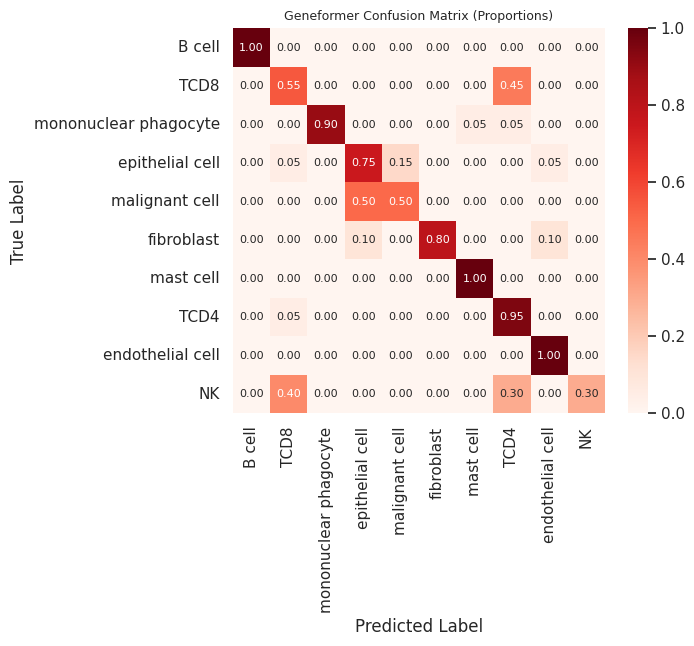

In [19]:
# Get confusion matrix 
conf_matrix = gf_finetuned_metrics["train_metrics"]["conf_matrix"]

# Normalize the confusion matrix to proportions
conf_matrix_row_normalized = conf_matrix.div(conf_matrix.sum(axis=1), axis=0)

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix_row_normalized, 
    annot=True,                 
    fmt=".2f",                  
    cmap="Reds",             
    annot_kws={"size": 8}      
)
plt.title("Geneformer Confusion Matrix (Proportions)", fontsize=9)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

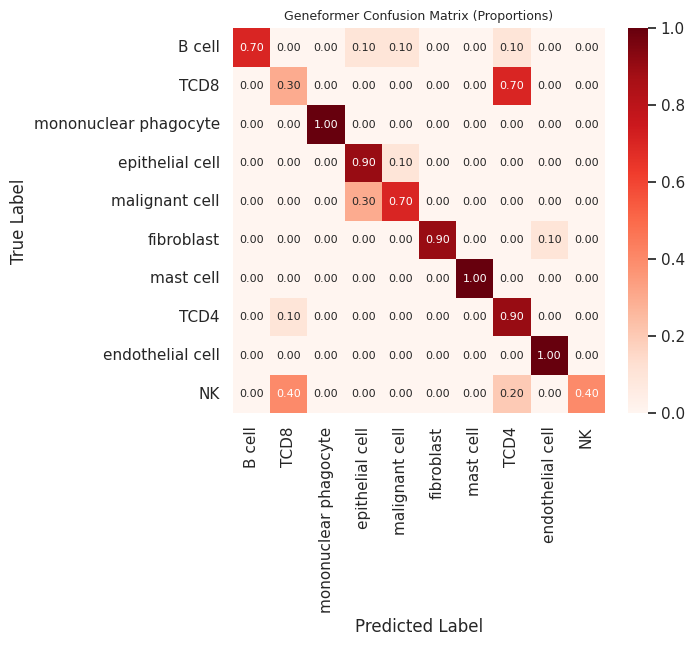

In [20]:
# Get confusion matrix 
conf_matrix = gf_finetuned_metrics["test_metrics"]["conf_matrix"]

# Normalize the confusion matrix to proportions
conf_matrix_row_normalized = conf_matrix.div(conf_matrix.sum(axis=1), axis=0)

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix_row_normalized, 
    annot=True,                 
    fmt=".2f",                  
    cmap="Reds",             
    annot_kws={"size": 8}      
)
plt.title("Geneformer Confusion Matrix (Proportions)", fontsize=9)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()